# Exercise: Generate and Visualize MNIST-like Images

## Your Task

In this exercise, you'll take the basic generator from the demo and implement the complete image generation pipeline:

1. **Sample noise vectors** from a Gaussian distribution
2. **Pass them through the generator** to create images


This exercise tests your understanding of:
- PyTorch tensor operations
- Visualization with Matplotlib and torchvision

## Learning Objectives

By the end, you should be able to:
-  Sample from a normal distribution correctly
-  Create image grids using `torchvision.utils.make_grid()`

## Instructions

Complete all **TODO** sections in this notebook. Hints are provided for each TODO.

## Part 1: Setup and Imports

In [2]:
import sys
from pathlib import Path

# Add project root to path so we can import models
sys.path.insert(0, str(Path().resolve().parent.parent.parent))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Import the generator from the demo
from models.basic_gan import create_generator

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
def visualize_generated_images(images, num_images=16, title="Generated Images"):
    """
    Visualize generated images in a grid.
    """
    # If images are flattened (784,), reshape to (batch_size, 1, 28, 28)
    if images.dim() == 2:
        images = images.view(-1, 1, 28, 28)

    # Take only num_images
    images = images[:num_images]

    # Denormalize from [-1, 1] to [0, 1] for visualization
    images = (images + 1) / 2

    # Create a grid using torchvision.utils
    grid = vutils.make_grid(images, nrow=4, normalize=False, padding=2)

    # Plot
    plt.figure(figsize=(8, 8))
    # Transpose from (C, H, W) to (H, W, C) and convert to numpy
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Step 1: Instantiate the generator

First, let's instantiate the generator. It's already untrained, which is fine - we just want to test the generation pipeline.

In [5]:
# Create generator
latent_dim = 100
batch_size = 16
generator = create_generator(latent_dim=latent_dim, device=device)
generator.eval()  # Set to evaluation mode

print("Generator created and ready to use")


Generator created and ready to use


## Part 3: TODO #1 - Sample Noise Vectors

**Your Task**: Sample 16 random noise vectors from a standard Gaussian distribution N(0, 1).

**Hints**:
- Use `torch.randn()` to sample from a normal distribution
- Shape should be (16, latent_dim) where latent_dim=100
- Remember to put it on the correct device
- Expected output: Tensor of shape `torch.Size([16, 100])`

In [6]:
# TODO #1: Sample 16 noise vectors from N(0, 1)
# Hints: torch.randn(shape).to(device)
noise_vectors = torch.randn(batch_size, latent_dim).to(device)

# Verify your result
if noise_vectors is not None:
    print(f"Noise shape: {noise_vectors.shape}")
    print(f"Expected:    torch.Size([16, 100])")
    print(f"Mean: {noise_vectors.mean():.3f} (should be ~0)")
    print(f"Std:  {noise_vectors.std():.3f} (should be ~1)")


Noise shape: torch.Size([16, 100])
Expected:    torch.Size([16, 100])
Mean: 0.011 (should be ~0)
Std:  0.995 (should be ~1)


## Part 4: TODO #2 - Generate Images

Pass your noise vectors through the generator to create 16 images.

**Hints**:
- Use `torch.no_grad()` context to disable gradient computation (faster, less memory)
- Output will be shape (16, 784) - a flattened 28×28 image for each noise vector
- The pixel values will be in [-1, 1] range (due to Tanh activation)

In [7]:
# TODO #2: Generate images from noise_vectors
# Use torch.no_grad() context, then call generator(noise_vectors)
with torch.no_grad():
    generated_images = generator(noise_vectors)



# Verify your result
if generated_images is not None:
    print(f"Generated images shape: {generated_images.shape}")
    print(f"Expected:               torch.Size([16, 784])")
    print(f"Pixel range: [{generated_images.min():.3f}, {generated_images.max():.3f}]")
    print(f"Should be in [-1, 1] range (due to Tanh)")


Generated images shape: torch.Size([16, 784])
Expected:               torch.Size([16, 784])
Pixel range: [-0.415, 0.418]
Should be in [-1, 1] range (due to Tanh)


## Part 5: TODO #6 - Visualize the Grid

Finally, display the image grid using Matplotlib,using image helper created

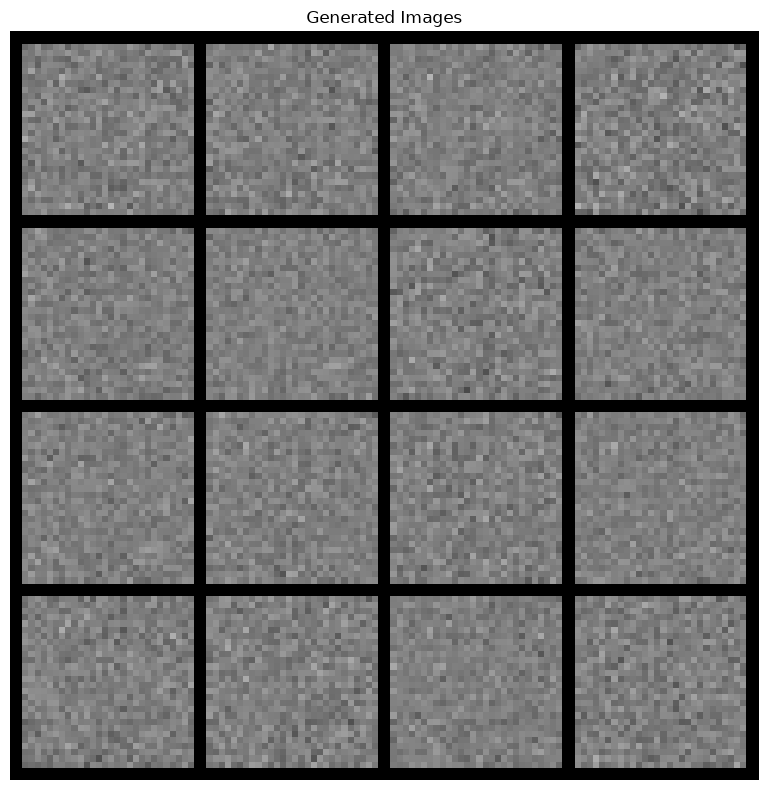

In [8]:
# TODO #6: Visualize the grid using helper

visualize_generated_images(generated_images, num_images=16, title="Generated Images")

## Summary & Reflection

Congratulations! You've completed the exercise. Here are the key takeaways:

### What You Accomplished
+ Sampled 16 random noise vectors from a Gaussian distribution  
+ Passed them through the generator network  
+ Reshaped output from flat (784) to image format (28×28)  
+ Denormalized from [-1, 1] to [0, 1]  
+ Created and visualized a 4×4 image grid  

### What You Observed
- The generator is **untrained**, so output looks like random noise
- Real MNIST digits have clear structure and patterns
- This shows why **training** is essential for generative models


